# Binary Classification Model. Train image model to recognise cat or dog

## Set Up Environment

In [1]:
# ensure internet is turned on
import socket,warnings
try:
    socket.setdefaulttimeout(1)
    socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect(('1.1.1.1', 53))
except socket.error as ex: raise Exception("STOP: No internet. Click '>|' in top right and set 'Internet' switch to on")

In [2]:
!python --version
!pip --version

Python 3.12.13
pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)


In [3]:
!pip install -U fastai 

## Preparing Dataset

In [4]:
from fastai.vision.all import *

set_seed(42, reproducible=True)

path = untar_data(URLs.PETS)
print(path)

<div><progress max="811706944" value="811712512"></progress> 100.00% [811712512/811706944 00:13&lt;00:00]</div>

/root/.fastai/data/oxford-iiit-pet


In [5]:
# for this dataset cat label start with uppercase and dog start with lowercase
def is_cat(label):
    return label[0].isupper()

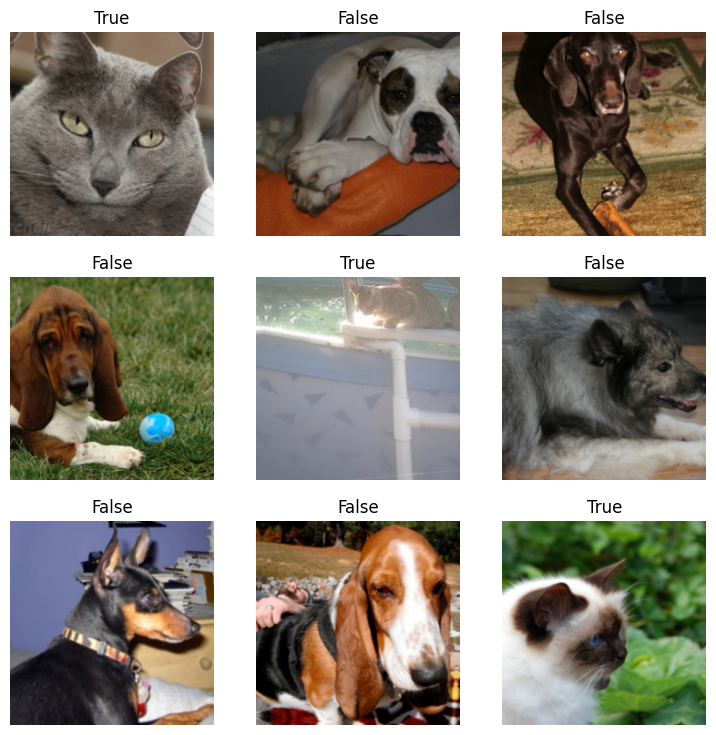

In [6]:
dls = ImageDataLoaders.from_name_func(
    path=path,
    fnames=get_image_files(path/"images"),
    label_func=is_cat,
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(),
    valid_pct=0.2
)

dls.show_batch(max_n=9)

In [7]:
print(f"n train: {len(dls.train_ds)}")
print(f"n validation: {len(dls.valid_ds)}")
print(f"n unique categories: {len(dls.vocab)}")

n train: 5912
n validation: 1478
n unique categories: 2


## Train Model

In [8]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(4)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 192MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,0.153581,0.033744,0.010149,00:29


epoch,train_loss,valid_loss,error_rate,time
0,0.053972,0.016888,0.002706,00:35
1,0.056038,0.018701,0.006766,00:36
2,0.031199,0.011027,0.003383,00:37
3,0.018579,0.009122,0.003383,00:38


<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

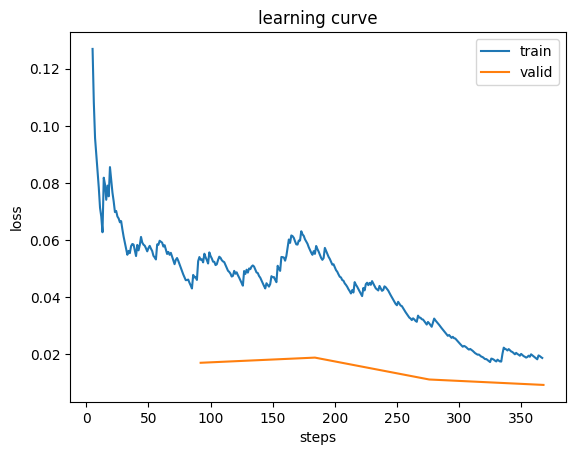

In [9]:
learn.recorder.plot_loss()

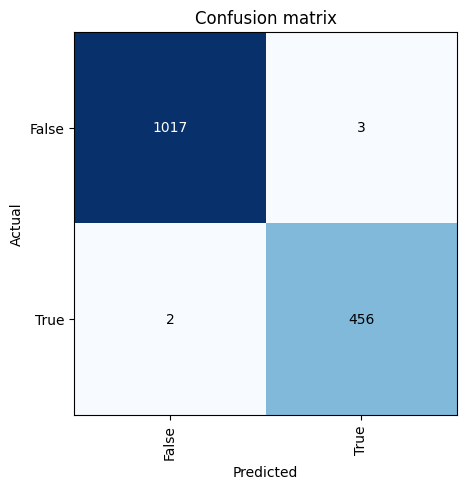

In [10]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

## Using Model

In [11]:
learn.export('./dog_cat_classifier.pkl')

In [12]:
import ipywidgets as widgets

# create image uploader
uploader = widgets.FileUpload()
uploader

FileUpload(value=(), description='Upload')

In [13]:
import io
from pathlib import Path

fallback_image_path = Path("/kaggle/input/datasets/reaksmeynou/test-sample/cat-1.jpg")

if uploader.value:
    uploaded_file = uploader.value[0] if isinstance(uploader.value, tuple) else list(uploader.value.values())[0]
    content = uploaded_file['content'] if isinstance(uploaded_file, dict) else uploaded_file.content
    img = PILImage.create(io.BytesIO(content))
elif fallback_image_path.exists():
    print("No file uploaded; using fallback image.")
    img = PILImage.create(fallback_image_path)
else:
    img = None
    print("No file uploaded and fallback image not found.")

if img is not None:
    is_cat, _, probs = learn.predict(img)        
    print(f"Cat or Dog?: {"🐱" if is_cat else "🐶"}")
    print(f"Probability it's a cat: {probs[1].item():.6f}")

No file uploaded; using fallback image.


Cat or Dog?: 🐱
Probability it's a cat: 1.000000
